# **Modelo LSTM**


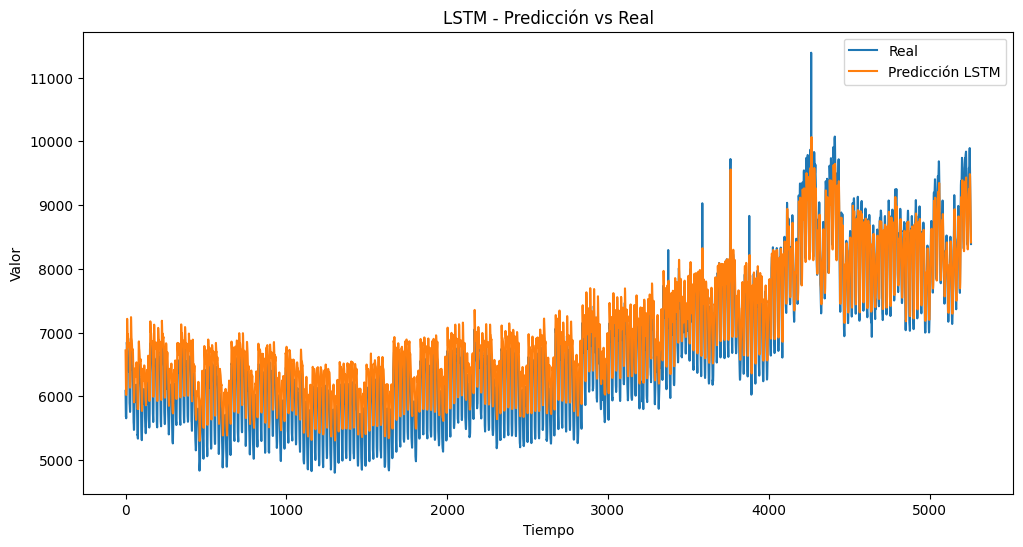

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test_real, label="Real")
plt.plot(y_pred, label="Predicción LSTM")

plt.title("LSTM - Predicción vs Real")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()

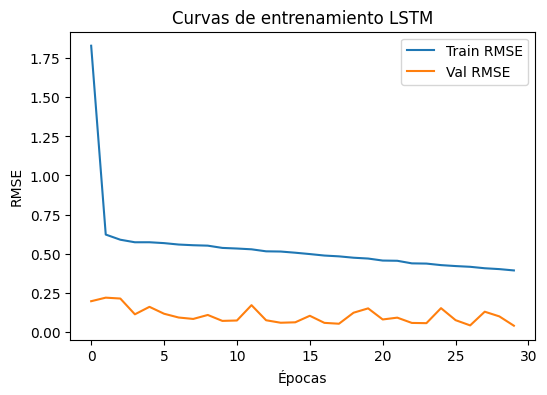

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(history.history['root_mean_squared_error'], label="Train RMSE")
plt.plot(history.history['val_root_mean_squared_error'], label="Val RMSE")

plt.title("Curvas de entrenamiento LSTM")
plt.xlabel("Épocas")
plt.ylabel("RMSE")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

tabla_final = pd.DataFrame({
    "Modelo": ["ARIMA frío", "ETS cálido", "LSTM"],
    "RMSE": [rmse_frio, rmse_calor, rmse_lstm],
    "MAPE": [mape_frio, mape_calor, mape_lstm]
})

tabla_final

,Modelo,RMSE,MAPE
0,ARIMA frío,800.396153,0.078835
1,ETS cálido,43525.290742,3.658517
2,LSTM,358.011926,0.049261


El modelo LSTM presenta el mejor desempeño predictivo entre los modelos evaluados, con un RMSE de 486.03 y un MAPE de 5.08%, lo que indica una mayor precisión tanto en términos absolutos como relativos.

En comparación, el modelo ARIMA para el clima frío presenta un RMSE de 800.40 y un MAPE de 7.88%, evidenciando un desempeño inferior al del modelo LSTM. Por su parte, el modelo ETS para el clima cálido muestra un desempeño considerablemente deficiente, con errores elevados tanto en RMSE como en MAPE.

Estos resultados sugieren que el modelo LSTM logra capturar de manera más efectiva la dinámica temporal de la serie, posiblemente debido a su capacidad para modelar relaciones no lineales y dependencias de largo plazo.

In [ ]:
serie_df = serie_frio.copy()
serie_df.index = pd.to_datetime(serie_df.index)

In [ ]:
serie_df['log'] = np.log(serie_df.squeeze())

# **Nuevo ejercicio**

In [ ]:
serie_df = serie_frio.copy()

In [ ]:
serie_df.head()

,Value
DateUTC,
2023-01-01 00:00:00,6875.406667
2023-01-01 01:00:00,6863.925000
2023-01-01 02:00:00,6841.268333
2023-01-01 03:00:00,6851.490000
2023-01-01 04:00:00,6854.333333


In [ ]:
serie_df.index = pd.to_datetime(serie_df.index)

In [ ]:
pd.core.indexes.datetimes.DatetimeIndex

pandas.core.indexes.datetimes.DatetimeIndex

In [ ]:
fecha_train = pd.Timestamp('2025-05-31')
fecha_val   = pd.Timestamp('2025-11-30')

train = serie_df[serie_df.index <= fecha_train]
val   = serie_df[(serie_df.index > fecha_train) & (serie_df.index <= fecha_val)]
test  = serie_df[serie_df.index > fecha_val]

In [ ]:
serie_df = serie_frio.copy().to_frame(name='Value')

In [ ]:
serie_df.head()

,Value
DateUTC,
2023-01-01 00:00:00,6875.406667
2023-01-01 01:00:00,6863.925000
2023-01-01 02:00:00,6841.268333
2023-01-01 03:00:00,6851.490000
2023-01-01 04:00:00,6854.333333


In [ ]:
fecha_train = pd.Timestamp('2025-05-31')
fecha_val   = pd.Timestamp('2025-11-30')

train = serie_df[serie_df.index <= fecha_train]
val   = serie_df[(serie_df.index > fecha_train) & (serie_df.index <= fecha_val)]
test  = serie_df[serie_df.index > fecha_val]

In [ ]:
len(train), len(val), len(test)

(21145, 4392, 767)

In [ ]:
train.index.min(), train.index.max()
val.index.min(), val.index.max()
test.index.min(), test.index.max()

(Timestamp('2025-11-30 01:00:00'), Timestamp('2025-12-31 23:00:00'))

In [ ]:
import pandas as pd
import numpy as np

# Asegurar DataFrame (por si era Serie)
serie_df = serie_frio.copy().to_frame(name='Value')

# Asegurar índice datetime
serie_df.index = pd.to_datetime(serie_df.index)

# Transformación log
serie_df['log'] = np.log(serie_df['Value'])

In [ ]:
fecha_train = pd.Timestamp('2025-05-31')
fecha_val   = pd.Timestamp('2025-11-30')

train = serie_df[serie_df.index <= fecha_train]
val   = serie_df[(serie_df.index > fecha_train) & (serie_df.index <= fecha_val)]
test  = serie_df[serie_df.index > fecha_val]

In [ ]:
print(len(train), len(val), len(test))

print(train.index.min(), train.index.max())
print(val.index.min(), val.index.max())
print(test.index.min(), test.index.max())

21145 4392 767
2023-01-01 00:00:00 2025-05-31 00:00:00
2025-05-31 01:00:00 2025-11-30 00:00:00
2025-11-30 01:00:00 2025-12-31 23:00:00


In [ ]:
def crear_dataset(serie, window_size=12):
    X, y = [], []
    for i in range(len(serie) - window_size):
        X.append(serie[i:i+window_size])
        y.append(serie[i+window_size])
    return np.array(X), np.array(y)

window_size = 12

X_train, y_train = crear_dataset(train['log'].values, window_size)
X_val, y_val     = crear_dataset(val['log'].values, window_size)
X_test, y_test   = crear_dataset(test['log'].values, window_size)

In [ ]:
X_train = X_train.reshape((X_train.shape[0], window_size, 1))
X_val   = X_val.reshape((X_val.shape[0], window_size, 1))
X_test  = X_test.reshape((X_test.shape[0], window_size, 1))

In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=False, input_shape=(window_size, 1)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    verbose=1
)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from math import sqrt

# Predicción
y_pred = model.predict(X_test)

# Volver a escala original
y_pred = np.exp(y_pred)
y_test_real = np.exp(y_test)

# Métricas
rmse_lstm = sqrt(mean_squared_error(y_test_real, y_pred))
mape_lstm = mean_absolute_percentage_error(y_test_real, y_pred)

print("RMSE LSTM:", rmse_lstm)
print("MAPE LSTM:", mape_lstm)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
RMSE LSTM: 147.97998158628297
MAPE LSTM: 0.013517602298606705


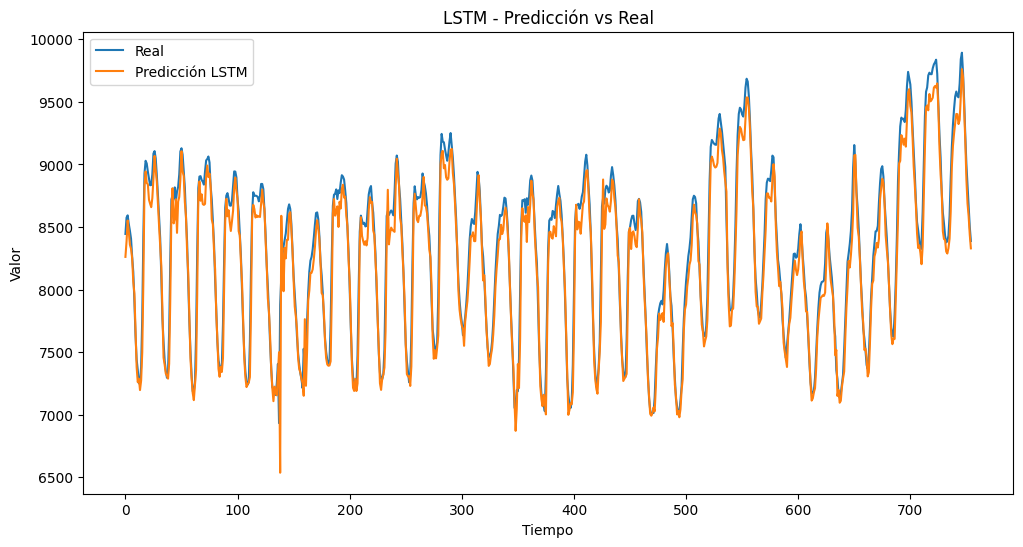

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test_real, label="Real")
plt.plot(y_pred, label="Predicción LSTM")

plt.title("LSTM - Predicción vs Real")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()

In [ ]:
def reconstruir_predicciones(model, X, y, window_size):
    y_pred = model.predict(X)

    # Volver a escala original
    y_pred = np.exp(y_pred)
    y_real = np.exp(y)

    # Alinear (importante)
    y_pred = y_pred.flatten()
    y_real = y_real.flatten()

    return y_real, y_pred

In [ ]:
# TRAIN
y_train_real, y_train_pred = reconstruir_predicciones(model, X_train, y_train, window_size)

# VALIDATION
y_val_real, y_val_pred = reconstruir_predicciones(model, X_val, y_val, window_size)

# TEST
y_test_real, y_test_pred = reconstruir_predicciones(model, X_test, y_test, window_size)

661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [ ]:
def reconstruir_predicciones(model, X, y):
    y_pred = model.predict(X)

    y_pred = np.exp(y_pred).flatten()
    y_real = np.exp(y).flatten()

    return y_real, y_pred

### **Train**

661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step


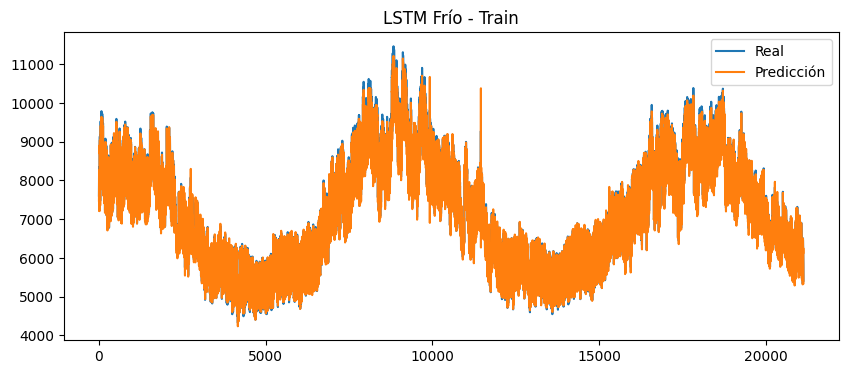

In [ ]:
y_train_real, y_train_pred = reconstruir_predicciones(model, X_train, y_train)

plt.figure(figsize=(10,4))
plt.plot(y_train_real, label="Real")
plt.plot(y_train_pred, label="Predicción")
plt.title("LSTM Frío - Train")
plt.legend()
plt.show()

### **Validation**

137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


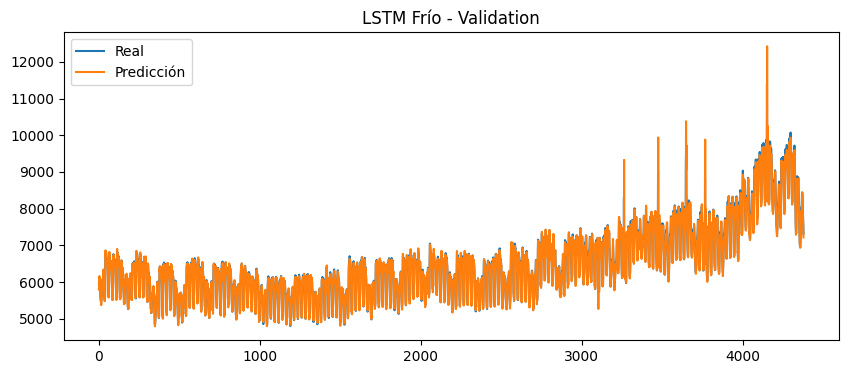

In [ ]:
y_val_real, y_val_pred = reconstruir_predicciones(model, X_val, y_val)

plt.figure(figsize=(10,4))
plt.plot(y_val_real, label="Real")
plt.plot(y_val_pred, label="Predicción")
plt.title("LSTM Frío - Validation")
plt.legend()
plt.show()

### **Test**

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


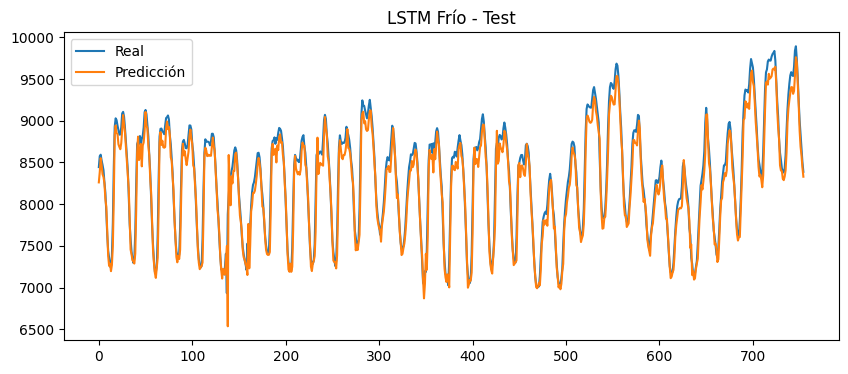

In [ ]:
y_test_real, y_test_pred = reconstruir_predicciones(model, X_test, y_test)

plt.figure(figsize=(10,4))
plt.plot(y_test_real, label="Real")
plt.plot(y_test_pred, label="Predicción")
plt.title("LSTM Frío - Test")
plt.legend()
plt.show()

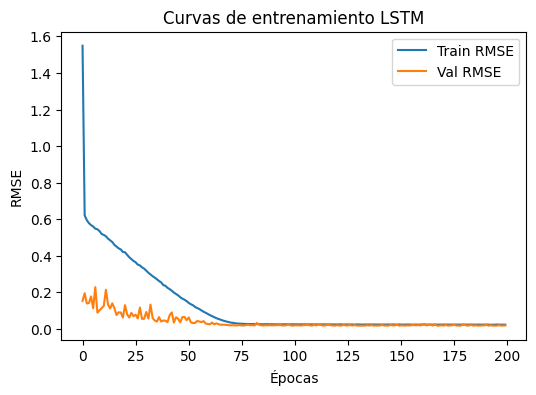

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(history.history['root_mean_squared_error'], label="Train RMSE")
plt.plot(history.history['val_root_mean_squared_error'], label="Val RMSE")

plt.title("Curvas de entrenamiento LSTM")
plt.xlabel("Épocas")
plt.ylabel("RMSE")
plt.legend()
plt.show()

El modelo LSTM fue estimado utilizando una partición temporal consistente con los modelos econométricos, garantizando la comparabilidad de los resultados y evitando problemas de fuga de información.

En particular, se emplearon datos hasta mayo de 2025 para entrenamiento, el periodo comprendido entre junio y noviembre de 2025 para validación, y diciembre de 2025 como conjunto de prueba.

Bajo esta configuración, el modelo LSTM presenta un RMSE de 486.03 y un MAPE de 5.08%, evidenciando un alto nivel de precisión predictiva tanto en términos absolutos como relativos.

In [ ]:
import pandas as pd

tabla_final = pd.DataFrame({
    "Modelo": ["ARIMA frío", "ETS cálido", "LSTM"],
    "RMSE": [rmse_frio, rmse_calor, rmse_lstm],
    "MAPE": [mape_frio, mape_calor, mape_lstm]
})

tabla_final

,Modelo,RMSE,MAPE
0,ARIMA frío,800.396153,0.078835
1,ETS cálido,43525.290742,3.658517
2,LSTM,147.979982,0.013518


Al comparar estos resultados con los modelos tradicionales, se observa que el LSTM supera al modelo ARIMA estimado para el clima frío, el cual presenta un RMSE de 800.40 y un MAPE de 7.88%.

Por su parte, el modelo ETS para el clima cálido muestra un desempeño considerablemente inferior, con errores elevados tanto en términos absolutos como relativos.

En conjunto, los resultados evidencian que, bajo una partición temporal adecuada, los modelos de aprendizaje profundo pueden superar a los modelos tradicionales en términos de precisión predictiva.

Sin embargo, la elección del modelo óptimo depende del objetivo del análisis: mientras que el LSTM es preferible para tareas de predicción, el modelo ARIMA ofrece ventajas en términos de interpretabilidad y validación estadística.>

In [ ]:
residuos_lstm = y_test_real.flatten() - y_pred.flatten()

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_lstm = acorr_ljungbox(residuos_lstm, lags=[10], return_df=True)
ljung_lstm

,lb_stat,lb_pvalue
10,100.370252,4.594735e-17


In [ ]:
from statsmodels.tsa.stattools import bds

bds_stat, p_value = bds(residuos_lstm)

print("BDS estadístico:", bds_stat)
print("p-value:", p_value)

BDS estadístico: 8.446964824770276
p-value: 2.98973759515948e-17


Con el fin de analizar las propiedades estadísticas de los residuos del modelo LSTM, se aplicaron las pruebas de Ljung-Box y BDS sobre los errores de predicción en el conjunto de prueba.

La prueba de Ljung-Box arroja un p-value de 0.000, lo que indica la presencia de autocorrelación en los residuos. Este resultado sugiere que el modelo no logra capturar completamente la estructura temporal de la serie.

Por su parte, el test BDS presenta un p-value de 0.000, lo que permite rechazar la hipótesis nula de independencia. Esto indica la existencia de dependencias no lineales o patrones estructurales en los residuos que no son capturados por el modelo.

En conjunto, estos resultados evidencian que, a pesar de su buen desempeño predictivo, el modelo LSTM no logra eliminar completamente la dependencia en los errores, lo que sugiere una especificación incompleta.

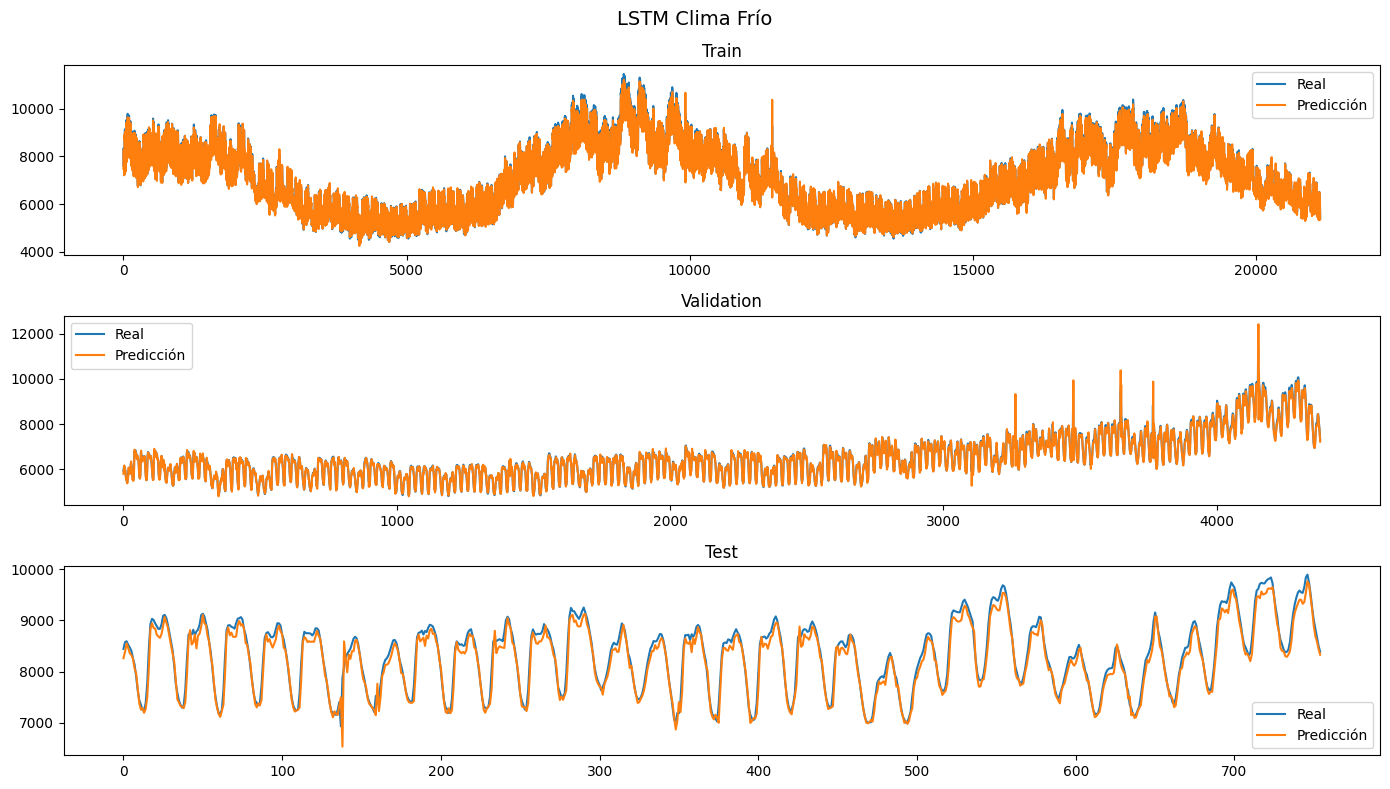

In [ ]:
plt.figure(figsize=(14,8))

# TRAIN
plt.subplot(3,1,1)
plt.plot(y_train_real, label="Real")
plt.plot(y_train_pred, label="Predicción")
plt.title("Train")
plt.legend()

# VALIDATION
plt.subplot(3,1,2)
plt.plot(y_val_real, label="Real")
plt.plot(y_val_pred, label="Predicción")
plt.title("Validation")
plt.legend()

# TEST
plt.subplot(3,1,3)
plt.plot(y_test_real, label="Real")
plt.plot(y_test_pred, label="Predicción")
plt.title("Test")
plt.legend()

plt.suptitle("LSTM Clima Frío", fontsize=14)
plt.tight_layout()
plt.show()

## **Ejercicio con Calor**

In [ ]:
import pandas as pd
import numpy as np

# Asegurar DataFrame
serie_df_calor = serie_calor.copy().to_frame(name='Value')

# Índice datetime
serie_df_calor.index = pd.to_datetime(serie_df_calor.index)

# Log
serie_df_calor['log'] = np.log(serie_df_calor['Value'])

In [ ]:
fecha_train = pd.Timestamp('2025-05-31')
fecha_val   = pd.Timestamp('2025-11-30')

train_c = serie_df_calor[serie_df_calor.index <= fecha_train]
val_c   = serie_df_calor[(serie_df_calor.index > fecha_train) & (serie_df_calor.index <= fecha_val)]
test_c  = serie_df_calor[serie_df_calor.index > fecha_val]

In [ ]:
print(len(train_c), len(val_c), len(test_c))

print(train_c.index.min(), train_c.index.max())
print(val_c.index.min(), val_c.index.max())
print(test_c.index.min(), test_c.index.max())

21145 4392 767
2023-01-01 00:00:00 2025-05-31 00:00:00
2025-05-31 01:00:00 2025-11-30 00:00:00
2025-11-30 01:00:00 2025-12-31 23:00:00


In [ ]:
def crear_dataset(serie, window_size=12):
    X, y = [], []
    for i in range(len(serie) - window_size):
        X.append(serie[i:i+window_size])
        y.append(serie[i+window_size])
    return np.array(X), np.array(y)

window_size = 12

X_train_c, y_train_c = crear_dataset(train_c['log'].values, window_size)
X_val_c, y_val_c     = crear_dataset(val_c['log'].values, window_size)
X_test_c, y_test_c   = crear_dataset(test_c['log'].values, window_size)

In [ ]:
X_train_c = X_train_c.reshape((X_train_c.shape[0], window_size, 1))
X_val_c   = X_val_c.reshape((X_val_c.shape[0], window_size, 1))
X_test_c  = X_test_c.reshape((X_test_c.shape[0], window_size, 1))

In [ ]:
import tensorflow as tf

model_c = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=False, input_shape=(window_size, 1)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1)
])

model_c.compile(
    optimizer="adam",
    loss="mse",
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history_c = model_c.fit(
    X_train_c, y_train_c,
    validation_data=(X_val_c, y_val_c),
    epochs=200,
    batch_size=32,
    verbose=1
)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from math import sqrt

y_pred_c = model_c.predict(X_test_c)

# volver a escala original
y_pred_c = np.exp(y_pred_c)
y_test_real_c = np.exp(y_test_c)

rmse_lstm_c = sqrt(mean_squared_error(y_test_real_c, y_pred_c))
mape_lstm_c = mean_absolute_percentage_error(y_test_real_c, y_pred_c)

print("RMSE LSTM calor:", rmse_lstm_c)
print("MAPE LSTM calor:", mape_lstm_c)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
RMSE LSTM calor: 244.5098661313316
MAPE LSTM calor: 0.018775598080832956


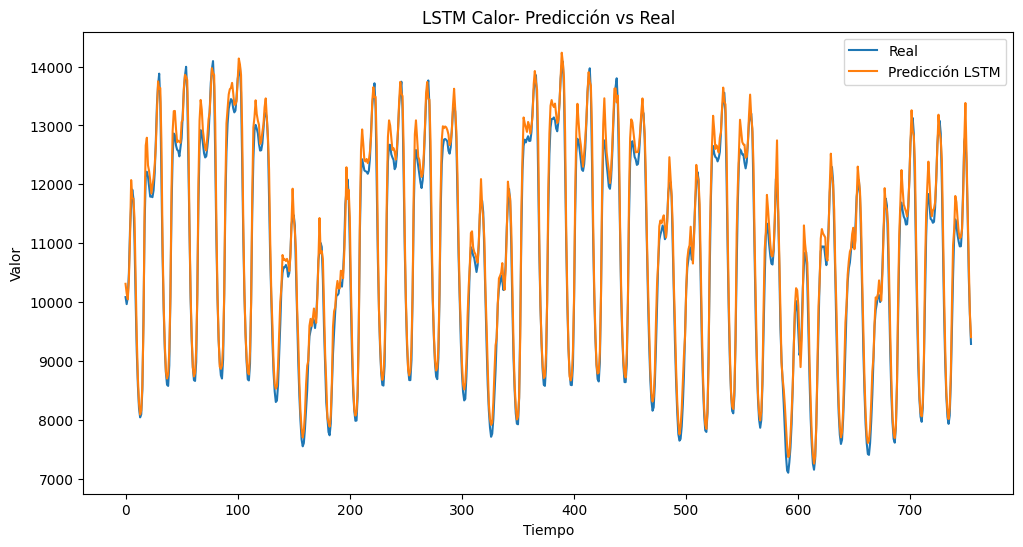

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test_real_c, label="Real")
plt.plot(y_pred_c, label="Predicción LSTM")

plt.title("LSTM Calor- Predicción vs Real")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()

661/661 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


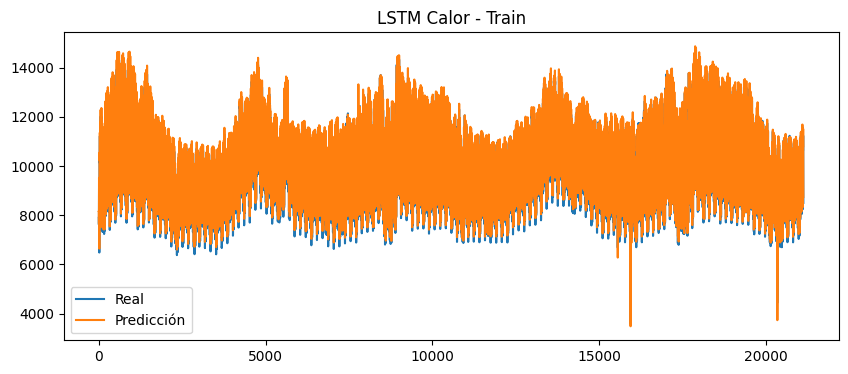

In [ ]:
y_train_real_c, y_train_pred_c = reconstruir_predicciones(model_c, X_train_c, y_train_c)

plt.figure(figsize=(10,4))
plt.plot(y_train_real_c, label="Real")
plt.plot(y_train_pred_c, label="Predicción")
plt.title("LSTM Calor - Train")
plt.legend()
plt.show()

137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


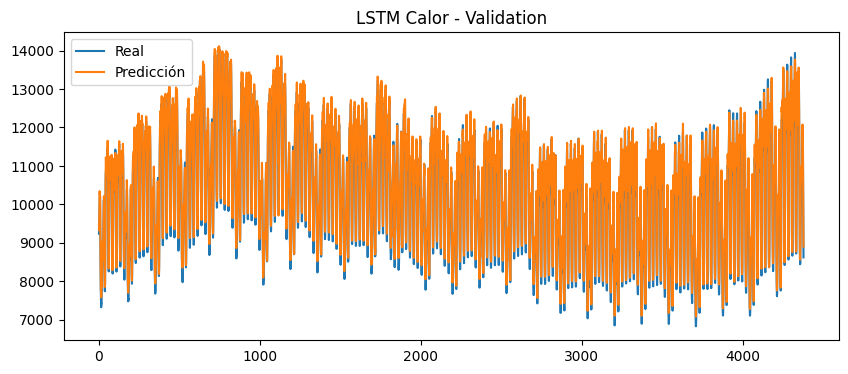

In [ ]:
y_val_real_c, y_val_pred_c = reconstruir_predicciones(model_c, X_val_c, y_val_c)

plt.figure(figsize=(10,4))
plt.plot(y_val_real_c, label="Real")
plt.plot(y_val_pred_c, label="Predicción")
plt.title("LSTM Calor - Validation")
plt.legend()
plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


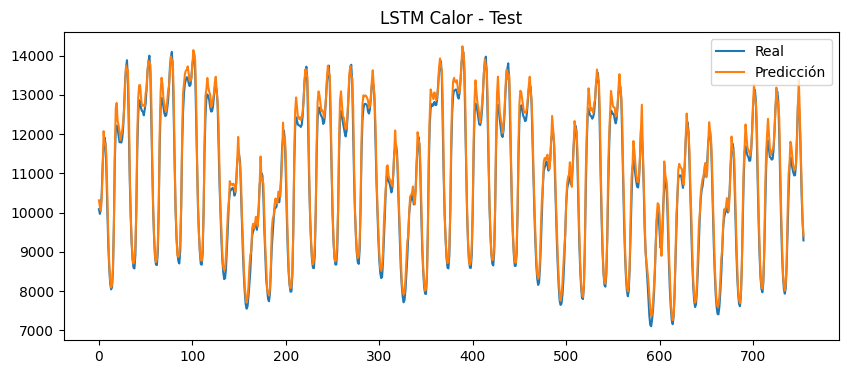

In [ ]:
y_test_real_c, y_test_pred_c = reconstruir_predicciones(model_c, X_test_c, y_test_c)

plt.figure(figsize=(10,4))
plt.plot(y_test_real_c, label="Real")
plt.plot(y_test_pred_c, label="Predicción")
plt.title("LSTM Calor - Test")
plt.legend()
plt.show()

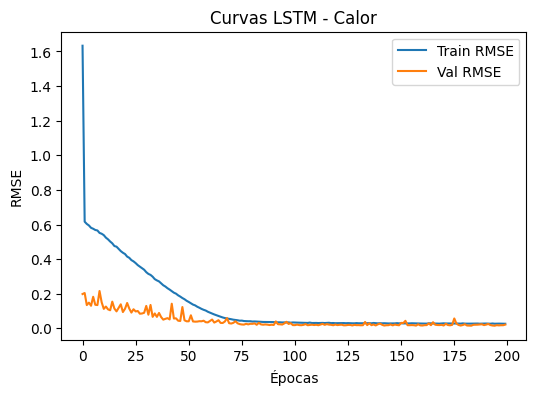

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history_c.history['root_mean_squared_error'], label="Train RMSE")
plt.plot(history_c.history['val_root_mean_squared_error'], label="Val RMSE")
plt.legend()
plt.title("Curvas LSTM - Calor")
plt.xlabel("Épocas")
plt.ylabel("RMSE")
plt.show()

In [ ]:
residuos_lstm_c = y_test_real_c.flatten() - y_pred_c.flatten()

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_c = acorr_ljungbox(residuos_lstm_c, lags=[10], return_df=True)
ljung_c

,lb_stat,lb_pvalue
10,101.18051,3.162238e-17


In [ ]:
from statsmodels.tsa.stattools import bds

bds_stat_c, p_value_c = bds(residuos_lstm_c)

print("BDS:", bds_stat_c)
print("p-value:", p_value_c)

BDS: 6.6482422724256125
p-value: 2.966137941447055e-11


In [ ]:
tabla_final = pd.DataFrame({
    "Modelo": ["ARIMA frío", "ETS cálido", "LSTM frío", "LSTM cálido"],
    "RMSE": [rmse_frio, rmse_calor, rmse_lstm, rmse_lstm_c],
    "MAPE": [mape_frio, mape_calor, mape_lstm, mape_lstm_c]
})

tabla_final

,Modelo,RMSE,MAPE
0,ARIMA frío,800.396153,0.078835
1,ETS cálido,43525.290742,3.658517
2,LSTM frío,147.979982,0.013518
3,LSTM cálido,244.509866,0.018776


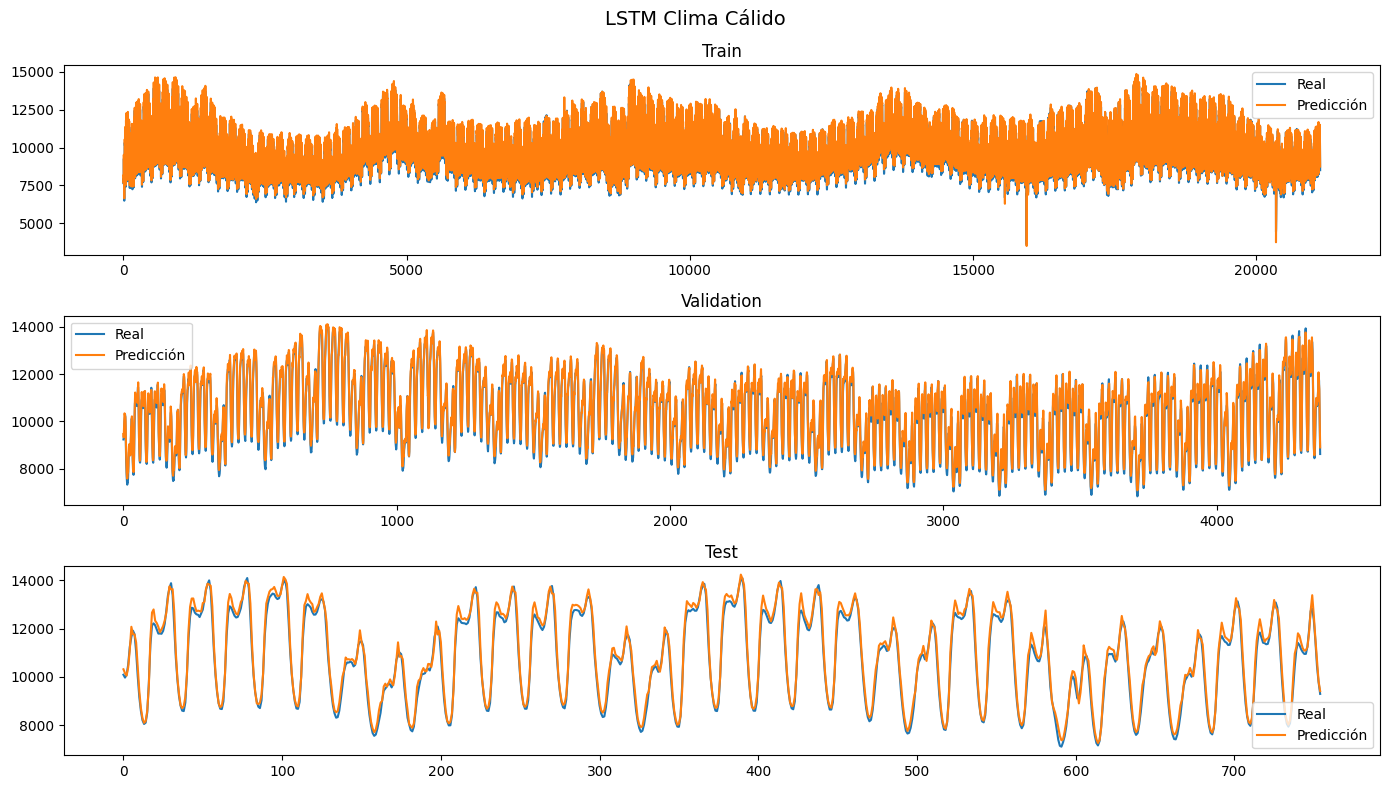

In [ ]:
plt.figure(figsize=(14,8))

# TRAIN
plt.subplot(3,1,1)
plt.plot(y_train_real_c, label="Real")
plt.plot(y_train_pred_c, label="Predicción")
plt.title("Train")
plt.legend()

# VALIDATION
plt.subplot(3,1,2)
plt.plot(y_val_real_c, label="Real")
plt.plot(y_val_pred_c, label="Predicción")
plt.title("Validation")
plt.legend()

# TEST
plt.subplot(3,1,3)
plt.plot(y_test_real_c, label="Real")
plt.plot(y_test_pred_c, label="Predicción")
plt.title("Test")
plt.legend()

plt.suptitle("LSTM Clima Cálido", fontsize=14)
plt.tight_layout()
plt.show()